# 2110233 Comp Eng Math Lab : Part Signals
## Done by : 6730084521 Chatrphol Ovanonchai

In [2]:
## Prerequisite
import numpy as np
import matplotlib.pyplot as plt
from sympy import pi, S, sympify , simplify

## Lab 01 - Intro to Signal processing
* Task 1 : Plot $x_0(t) = 2e^{j2 \pi t}$ (Plotting 3D and 2D seperately)

Text(0.5, 0, 'imag')

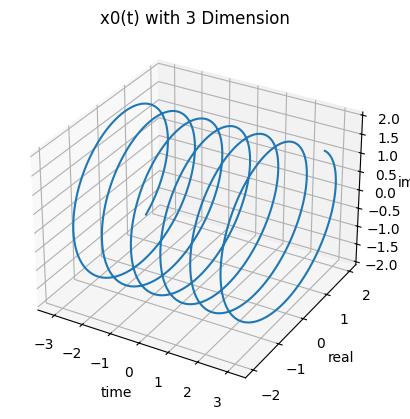

In [3]:
## 1st plot : 3D plotting

## Step 1 : create figure (for space) and ax (for subplot)
fig = plt.figure()
ax = plt.subplot(111 , projection = "3d") # 1st row , 1st col , first subplot

## Step 2 : define real and imag part of equation
time = np.arange(-np.pi , np.pi , 0.01) ## linspace similar as arange but needs specific #samples
x0_t = 2 * np.e ** (2 * 1j * np.pi * time)

real_x0 = np.real(x0_t) ; imag_x0 = np.imag(x0_t)

## Step 3 : use .plot3D method
ax.plot3D(time , real_x0 , imag_x0)

## decorate graph
ax.set_title("x0(t) with 3 Dimension")
ax.set_xlabel("time")
ax.set_ylabel("real")
ax.set_zlabel("imag")

Text(0, 0.5, 'value')

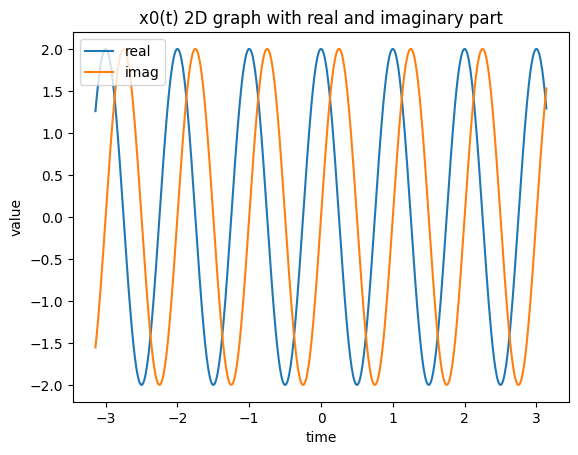

In [4]:
## Plot #2 : plotting real & image in same graph 
plt.plot(time , real_x0 , label = "real") # x = time , y = real 
plt.plot(time , imag_x0 , label = "imag") # x = time , y = imag
plt.legend(loc = "upper left") ## location of legend

plt.title("x0(t) 2D graph with real and imaginary part")
plt.xlabel("time")
plt.ylabel("value")

* Task 1 : $x_1(t) = sin(\frac{2 \pi  }{ 3}t) + sin(3 \pi t)  $

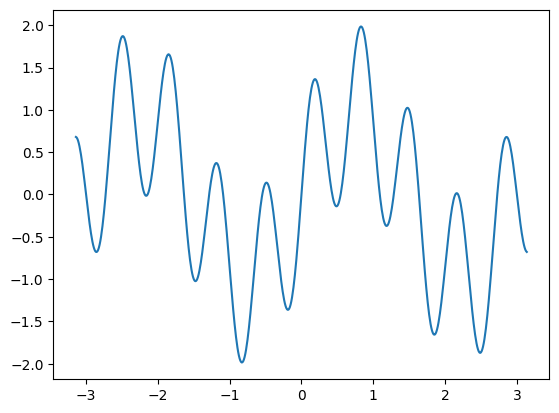

In [5]:
## define signal 
time = np.arange(-np.pi , np.pi , 0.01)
x1_t = np.sin( 2 / 3 * np.pi * time) + np.sin(3 * np.pi * time)

plt.plot(time , x1_t)

In [6]:
## check if this graph is periodic 
from sympy import S, simplify, lcm, pi  ## note that , we should use sympy "pi" for calculation

## Note : using sympy tools ("S" for sympify , "simplify" for making rational)

# Step 1 : calculate angular frequency
w1 = S(2) / 3 * pi # make 2 as sympi to not dividing number
w2 = 3 * pi

# Step 2 : make rational and check if periodic with w1 / w2 (same as T2 / T1 as k/l)
f_ratio = simplify(w1 / w2)
is_x1_periodic = f_ratio.is_rational # if not rational , will not be periodic (ex 3/2pi)

if (is_x1_periodic == True) : 
    # find period of each graph
    T1 = (2 * pi) / (w1)
    T2 = (2 * pi) / (w2)
    T_fund = lcm(T1,T2) # fundamental period = Tz
    print(f"Periodic of x1(t) is {T_fund} seconds")
    
else : 
    print("This graph is not periodic")

Periodic of x1(t) is 6 seconds


* Task 3 : $x_2(t) = sin(\frac{2 \pi  }{ 3}t) + sin(3 t)  $

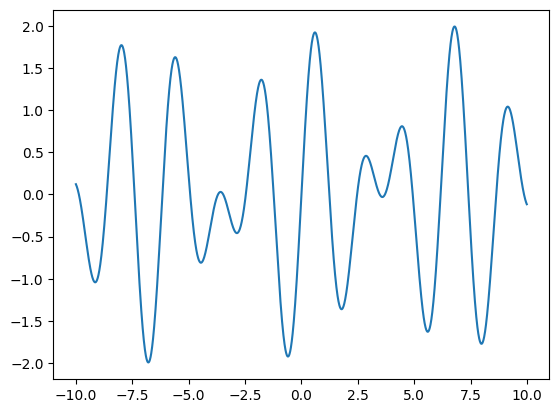

In [7]:
## define time & signal 
time = np.arange(-10 , 10 , 0.01)
x2_t = np.sin(2/3 * np.pi * time) + np.sin(3 * time) ## dont use sympi pi here , cant calculate
plt.plot(time , x2_t)

In [8]:
## check if this graph is periodic 
from sympy import S, simplify, lcm, pi  ## note that , we should use sympy "pi" for calculation

## Note : using sympy tools ("S" for sympify , "simplify" for making rational)

# Step 1 : calculate angular frequency
w1 = S(2) / 3 * pi # make 2 as sympi to not dividing number
w2 = 3 

# Step 2 : make rational and check if periodic with w1 / w2 (same as T2 / T1 as k/l)
f_ratio = simplify(w1 / w2)
is_x1_periodic = f_ratio.is_rational # if not rational , will not be periodic (ex 3/2pi)

if (is_x1_periodic == True) : 
    # find period of each graph
    T1 = (2 * pi) / (w1)
    T2 = (2 * pi) / (w2)
    T_fund = lcm(T1,T2) # fundamental period = Tz
    print(f"Periodic of x1(t) is {T_fund} seconds")
    
else : 
    print("This graph is not periodic")

This graph is not periodic


## Odd - Even Signal

x1_reflect = -x1


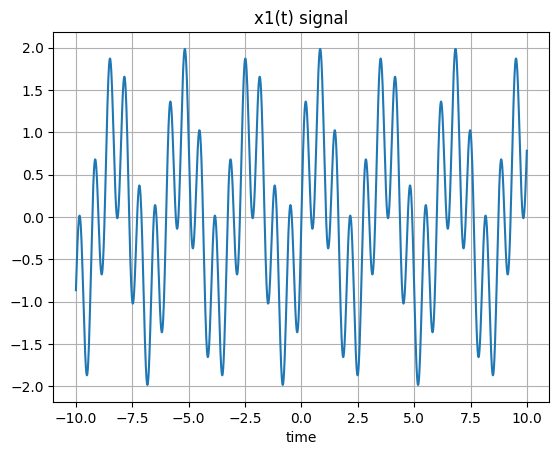

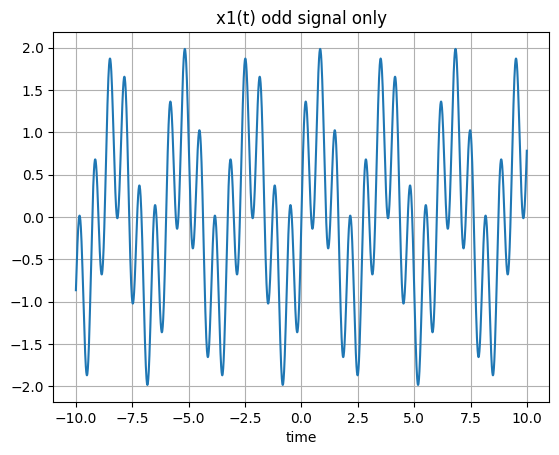

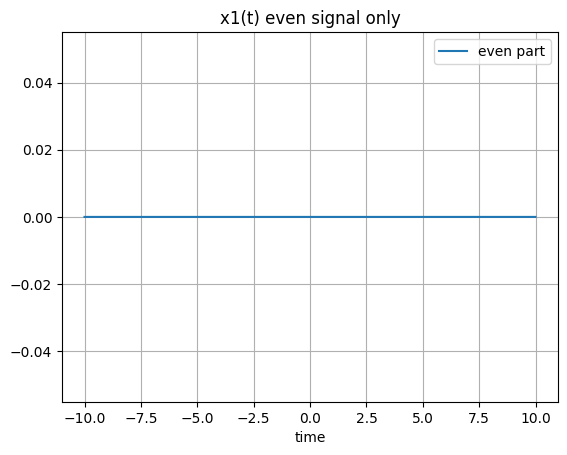

In [9]:
# define time and signal
time = np.arange(-10 , 10 , 0.01)
x1_t = np.sin(2 / 3 * np.pi * time) + np.sin(3 * np.pi * time)
x1_t_reflect = np.sin(-2 / 3 * np.pi * time) + np.sin( -3 * np.pi * time)
x1_negative = - x1_t ## define this to check if we put negative 

## we can summarize that : sin(-x) = -sinx [Odd signal]
print("x1_reflect = -x1" if (x1_negative == x1_t_reflect).all() else "x1_reflect != -x1")

## any signal can be decomposed into even & odd signal 
x1_even = 1/2 * (x1_t + x1_t_reflect)
x1_odd  = 1/2 * (x1_t - x1_t_reflect)


## Plot graph
plt.figure()
plt.plot(time , x1_t)
plt.title("x1(t) signal") ; plt.xlabel("time") ; plt.grid(True)
plt.show()
 
plt.figure()
plt.plot(time , x1_odd , label = "odd part")
plt.title("x1(t) odd signal only") ; plt.xlabel("time") ; plt.grid(True)
plt.show()

plt.figure()
plt.plot(time , x1_even , label = "even part")
plt.title("x1(t) even signal only") ; plt.xlabel("time") ; plt.grid(True)
plt.legend()
plt.show()

## So , x1(t) is sine function , which have only odd signal , no even signal

## Lab 02 - Convolution

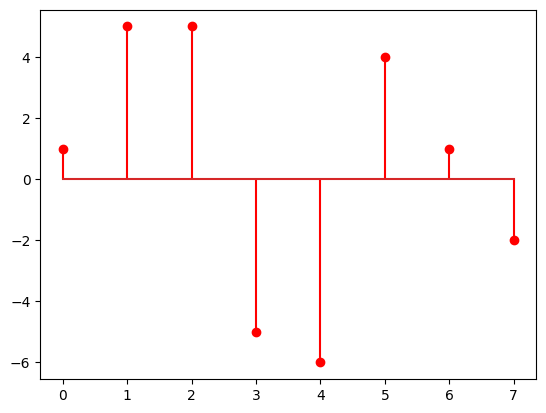

In [10]:
# Exercise 2.1
import numpy as np
import matplotlib.pyplot as plt

x1 = [1,3,-1,-2] # M = 4
h1 = [1,2,0,-1,1] # N = 5
y1 = np.convolve(h1, x1) # M+N-1 ตัว 8 ตัว
n = np.arange(0,len(y1),1)

plt.stem(n,y1,'r',markerfmt='or')
plt.show()

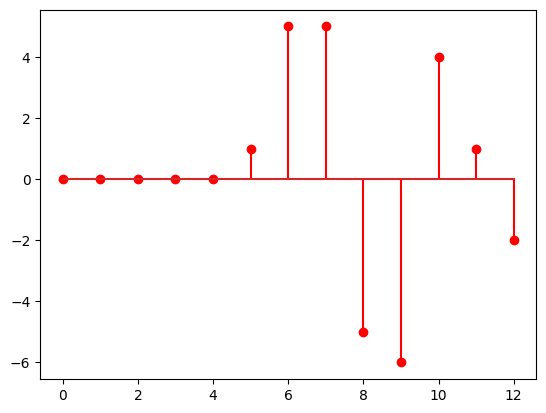

In [11]:
# Exercise 2.1
import numpy as np
import matplotlib.pyplot as plt

x1 = [0,0,1,3,-1,-2] # M = 4
h1 = [0,0,0,1,2,0,-1,1] # N = 5
y1 = np.convolve(h1, x1) # M+N-1 ตัว 8 ตัว
n = np.arange(0,len(y1),1)

plt.stem(n,y1,'r',markerfmt='or')
plt.show()

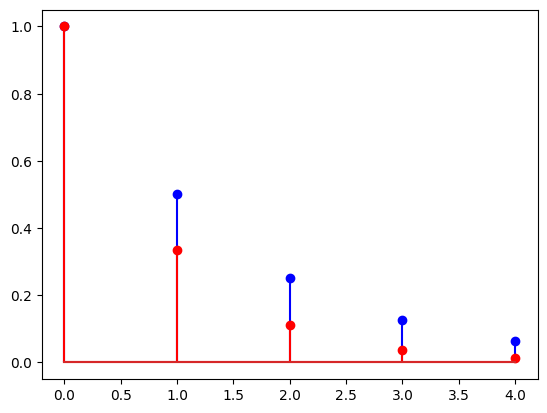

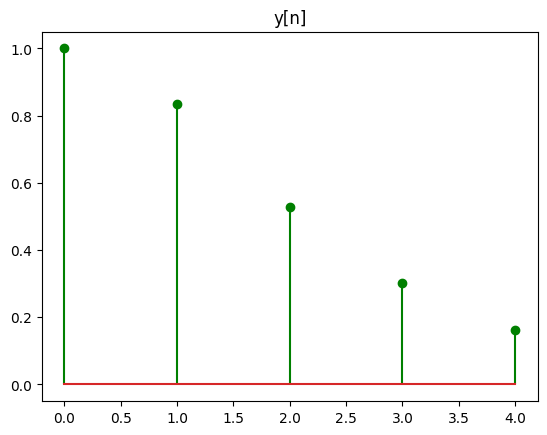

In [12]:
# Exercise 2.2
import numpy as np
import matplotlib.pyplot as plt

alpha = 1/2
beta = 1/3

n = np.arange(0,5,1)
x_n = alpha**n
h_n = beta**n
plt.stem(n,x_n,'b',markerfmt='ob')
plt.stem(n,h_n,'r',markerfmt='or')
plt.show()

y = beta**n * (1- (alpha/beta)**(n+1))/(1-alpha/beta)
plt.stem(n,y,'g',markerfmt='og'),plt.title("y[n]")
plt.show()

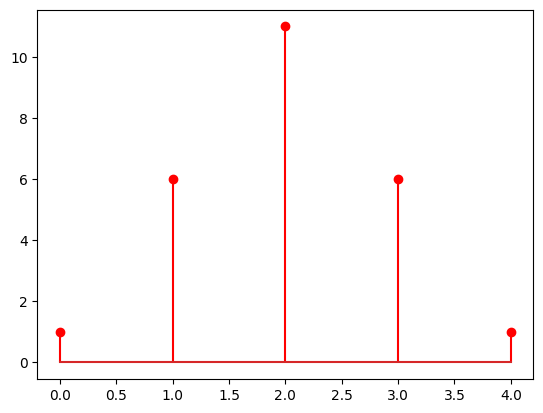

In [13]:
# Exercise 2.1
import numpy as np
import matplotlib.pyplot as plt

x1 = [1,3,1] # M = 4
h1 = [1,3,1] # N = 5
y1 = np.convolve(h1, x1) # M+N-1 ตัว 8 ตัว
n = np.arange(0,len(y1),1)

plt.stem(n,y1,'r',markerfmt='or')
plt.show()

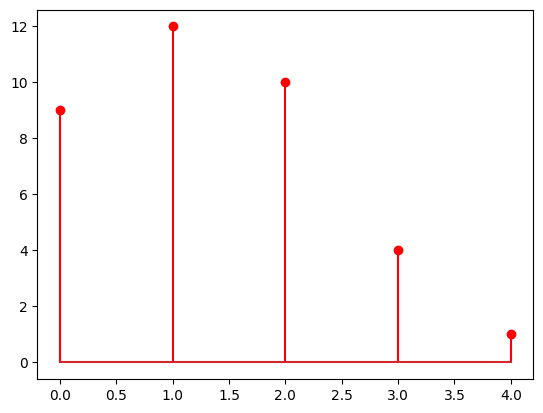

In [14]:
# Exercise 2.1
import numpy as np
import matplotlib.pyplot as plt

x1 = [3,2,1] # M = 4
h1 = [3,2,1] # N = 5
y1 = np.convolve(h1, x1) # M+N-1 ตัว 8 ตัว
n = np.arange(0,len(y1),1)

plt.stem(n,y1,'r',markerfmt='or')
plt.show()

## Lab 03 - Convolution & Fourier Series

2. $f_2(t) * g_2(t)$

In [15]:
from matplotlib import legend
import matplotlib.pyplot as plt
import numpy as np
t = np.arange(-1.5,0,0.01)
fg = _______________________
plt.plot(t,fg,label="1.25/pi * (1-sin (pi t))")


t2 = np.arange(0,0.5,0.01)
fg2 = _______________________
plt.plot(t2,fg2,label="1.25/pi * (cos (pi t) -sin (pi t))")


t3 = np.arange(0.5,2,0.01)
fg3 = _______________________
plt.plot(t3,fg3,label="1.25/pi * (cos (pi t))")

plt.legend(loc="upper right")
plt.show()

NameError: name '_______________________' is not defined

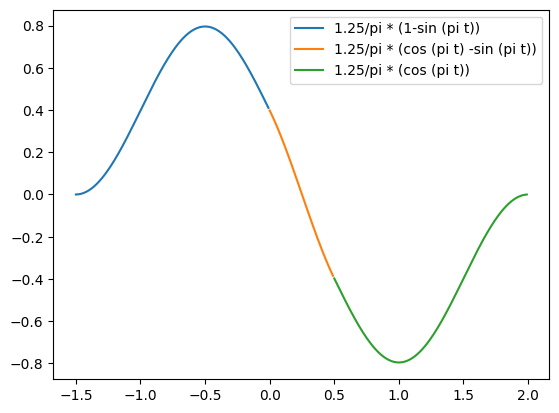

In [ ]:
from matplotlib import legend
import matplotlib.pyplot as plt
import numpy as np
t = np.arange(-1.5,0,0.01)
fg = 1.25/np.pi*(1-np.sin(np.pi*t))
plt.plot(t,fg,label="1.25/pi * (1-sin (pi t))")


t2 = np.arange(0,0.5,0.01)
fg2 = 1.25/np.pi*(np.cos(np.pi*t2)-np.sin(np.pi*t2))
plt.plot(t2,fg2,label="1.25/pi * (cos (pi t) -sin (pi t))")


t3 = np.arange(0.5,2,0.01)
fg3 = 1.25/np.pi*(np.cos(np.pi*t3)-1)
plt.plot(t3,fg3,label="1.25/pi * (cos (pi t))")

plt.legend(loc="upper right")
plt.show()

4. Fourier Series Representation

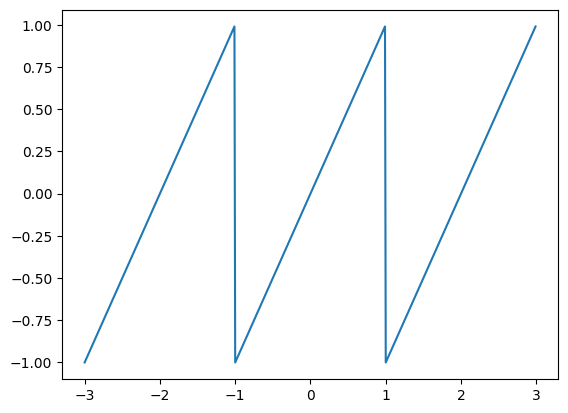

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

r = np.arange(-1,1,0.01)

t_0 = np.arange(-3,3,0.01)
x_t  = np.tile(r,3)
plt.plot(t_0,x_t)
plt.show()

### plot line spectra

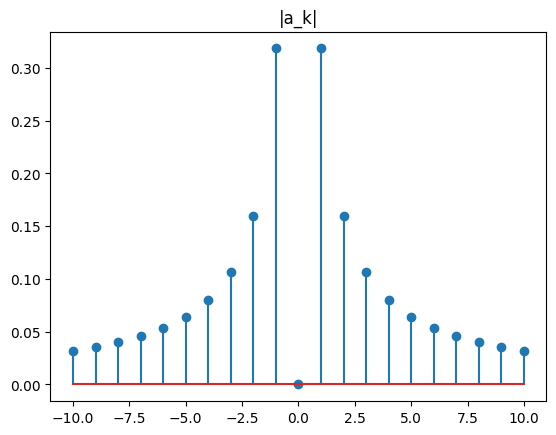

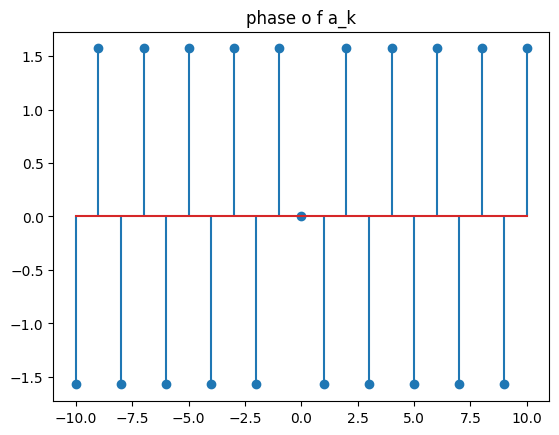

In [ ]:
# Plot line spectra
from matplotlib import legend
import matplotlib.pyplot as plt
import numpy as np

k = np.arange(-10,11,1, dtype=float)
a_k = (-1)**k * 1j / (k*np.pi+1e-5)
a_k[10] = 0
plt.stem(k,np.abs(a_k)); plt.title("|a_k|")
plt.show()

plt.stem(k,np.angle(a_k)); plt.title("phase o f a_k")
plt.show()

Plot each component so x(t) can be represented by Fourier series representation

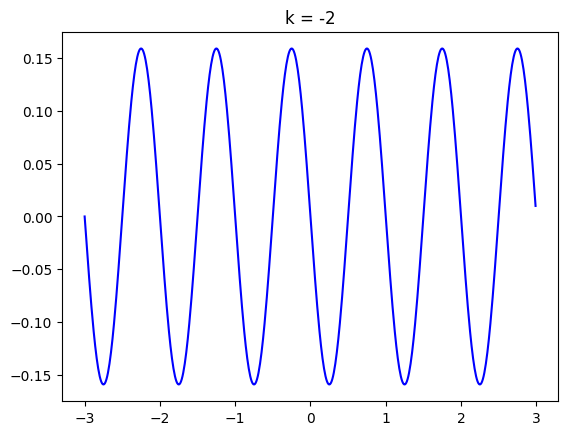

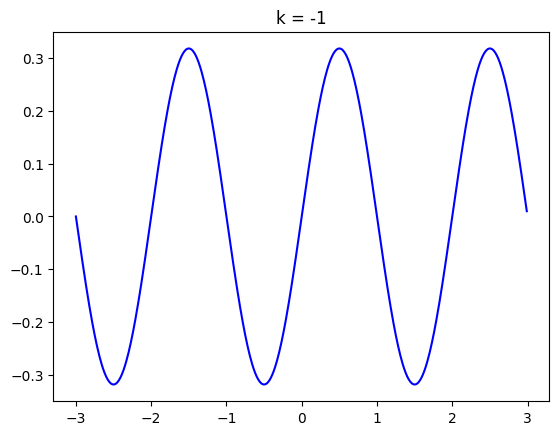

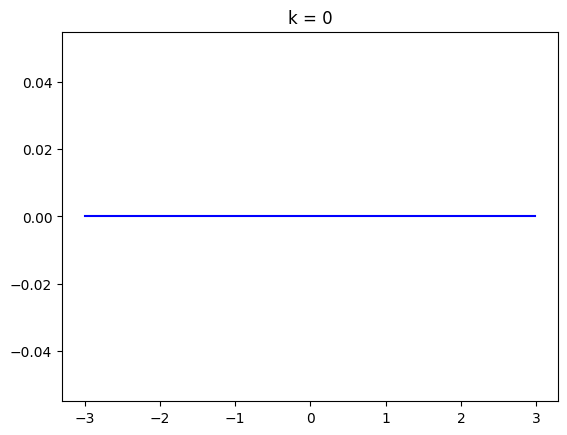

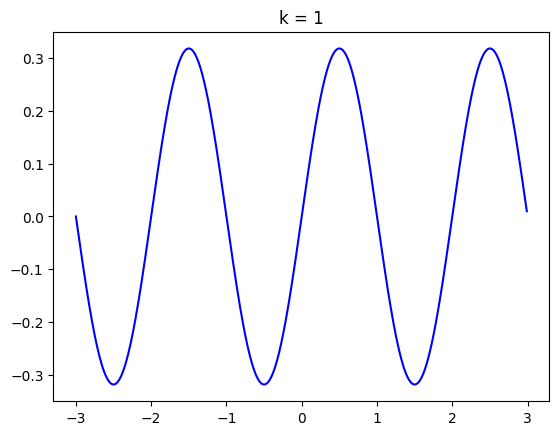

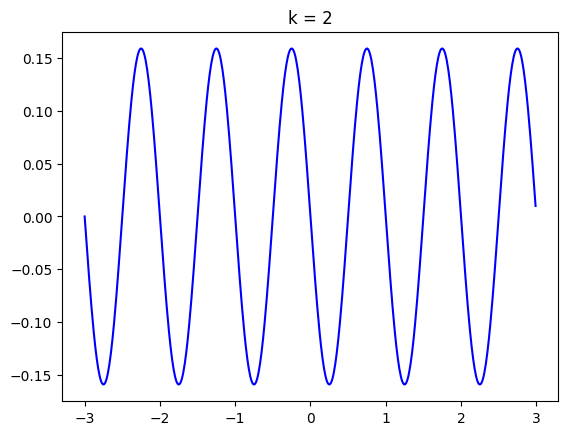

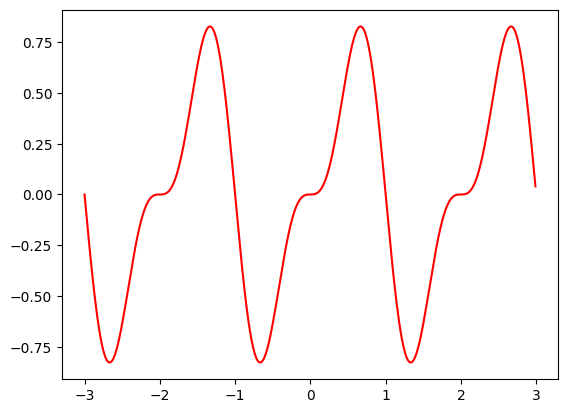

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t_0 = np.arange(-3,3,0.01)
x_t = np.zeros_like(t_0,dtype = 'complex128')

N = 2 # Try to change N
for k in range(-N,N+1,1):
  # TO DO: find a_k
  x_t_k = _____a_k___________ * np.e**(1j * np.pi * k * t_0)
  x_t += x_t_k
  plt.plot(t_0,x_t_k,color='b'); plt.title('k = '+str(k))
  plt.show()

plt.plot(t_0,x_t,color='r')
plt.show()

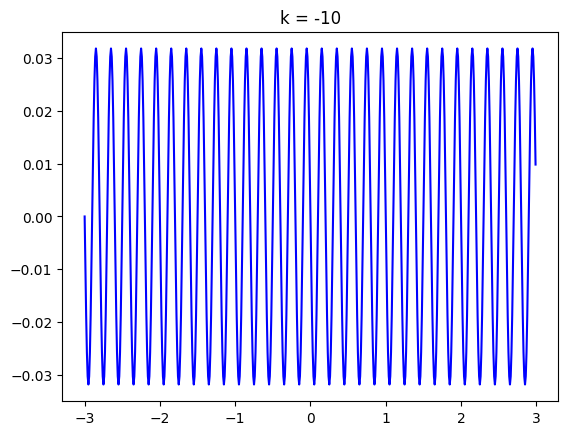

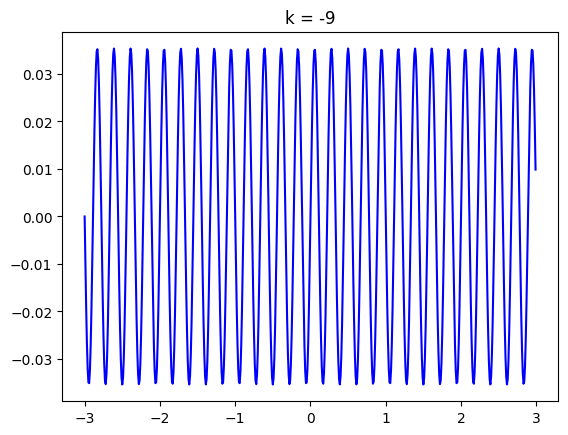

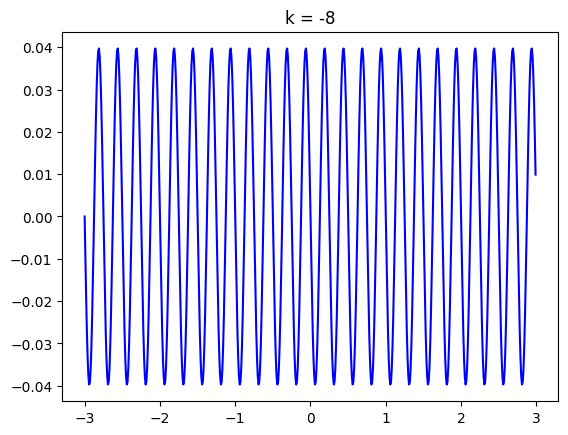

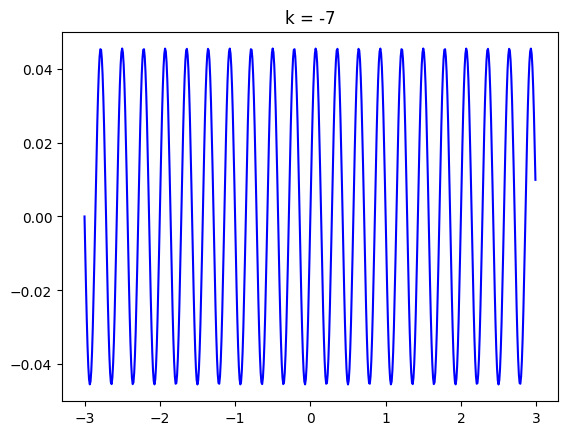

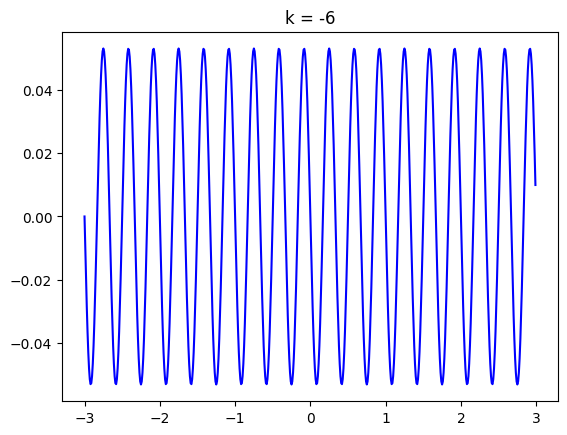

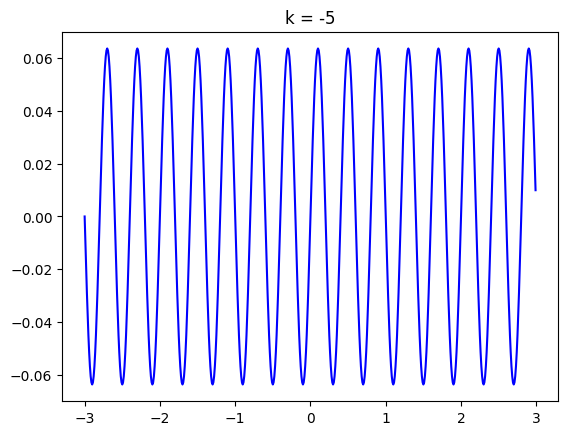

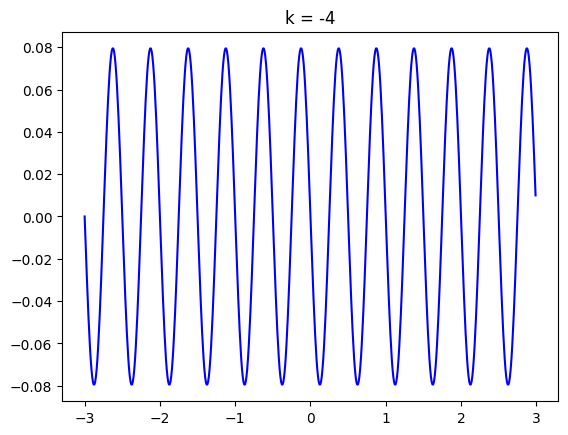

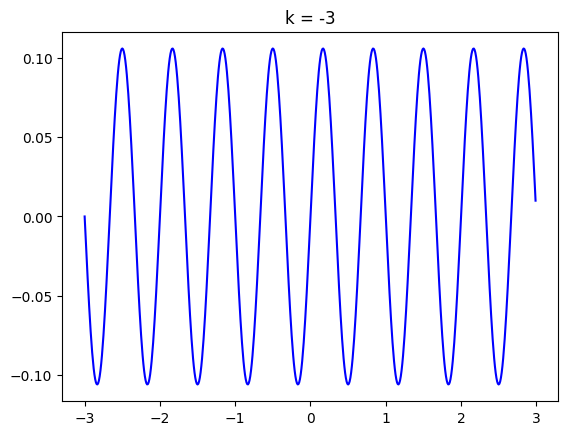

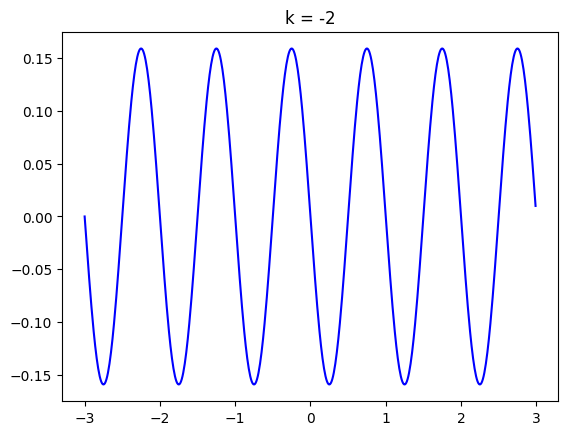

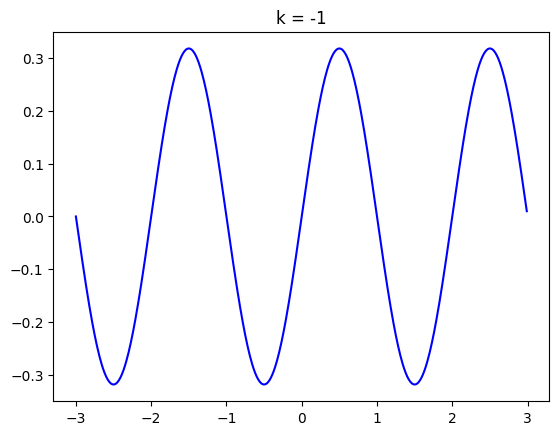

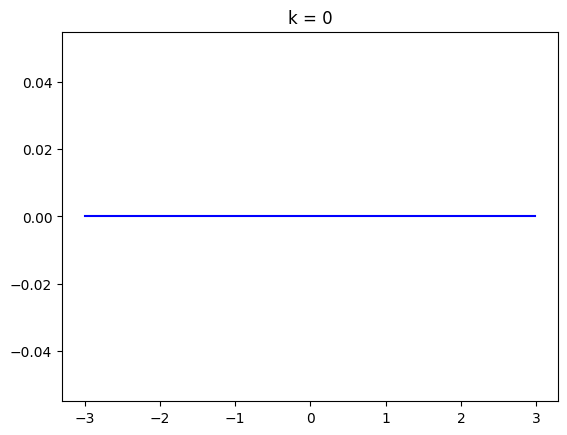

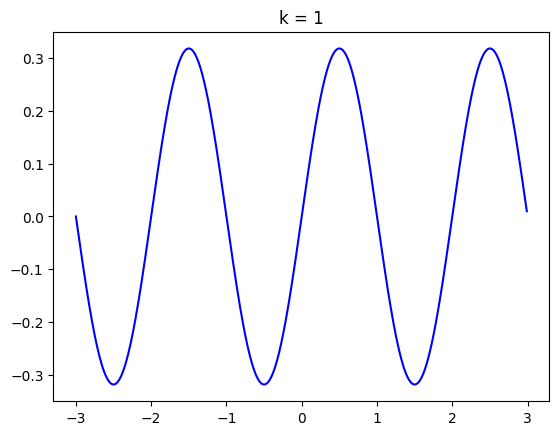

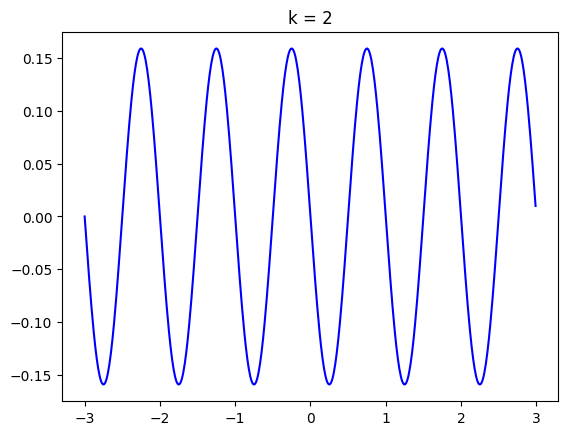

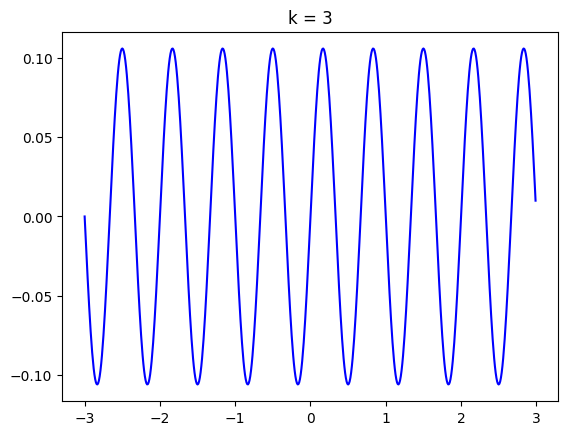

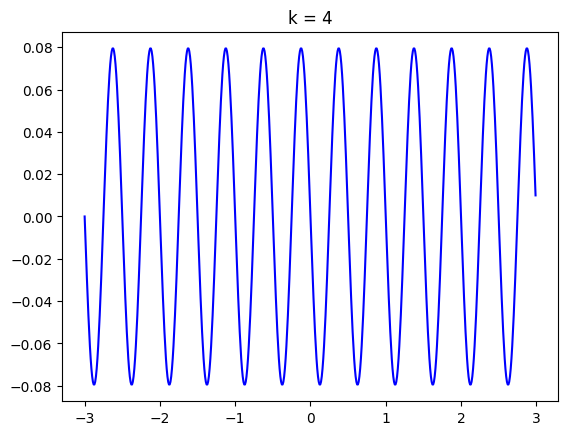

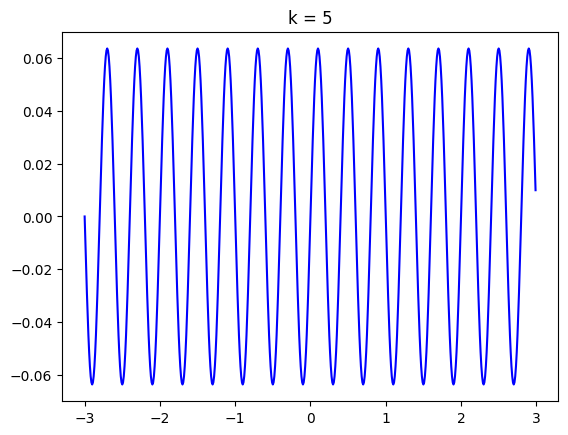

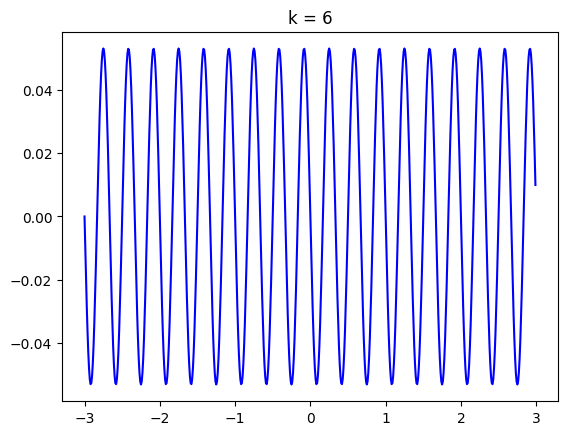

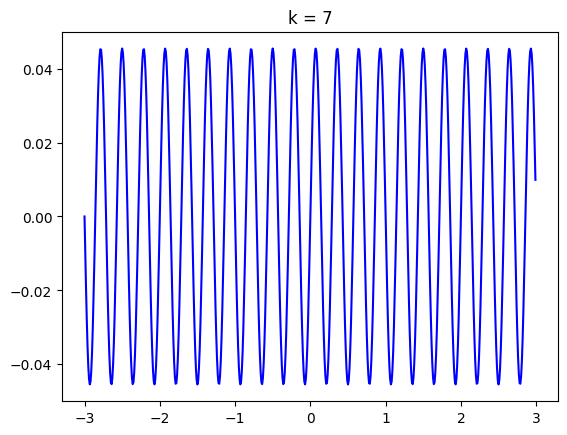

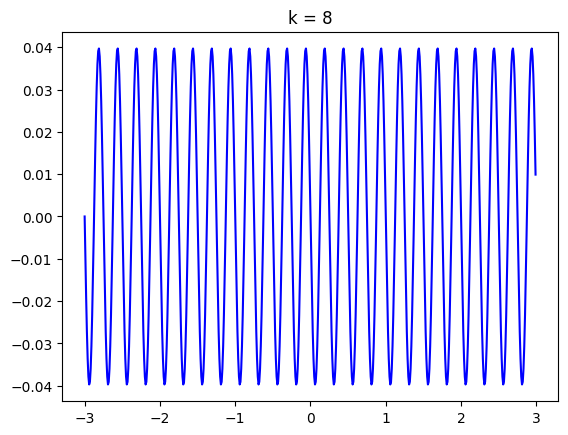

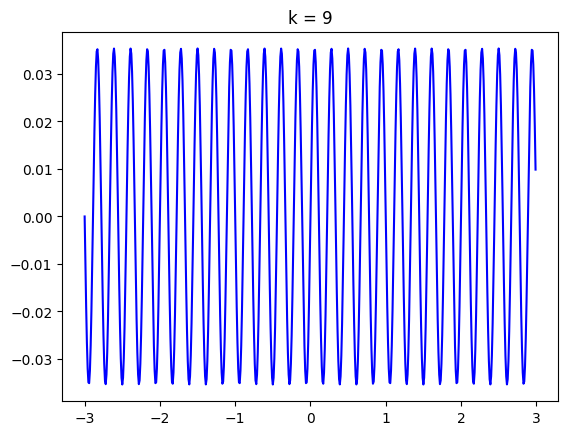

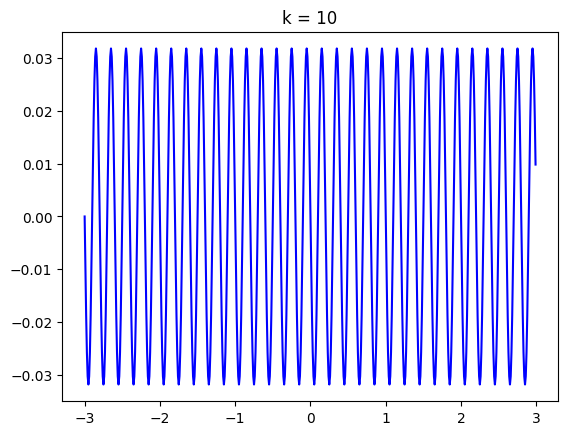

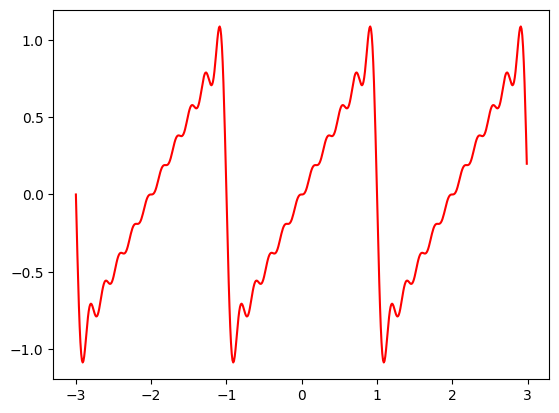

In [ ]:
t_0 = np.arange(-3,3,0.01)
x_t = np.zeros_like(t_0,dtype = 'complex128')

N = 10
for k in range(-N,N+1,1):
  x_t_k = (-1)**k * 1j / (k*np.pi + 1e-5) * np.e**(1j * np.pi * k * t_0)
  x_t += x_t_k
  plt.plot(t_0,x_t_k,color='b'); plt.title('k = '+str(k))
  plt.show()

plt.plot(t_0,x_t,color='r')
plt.show()

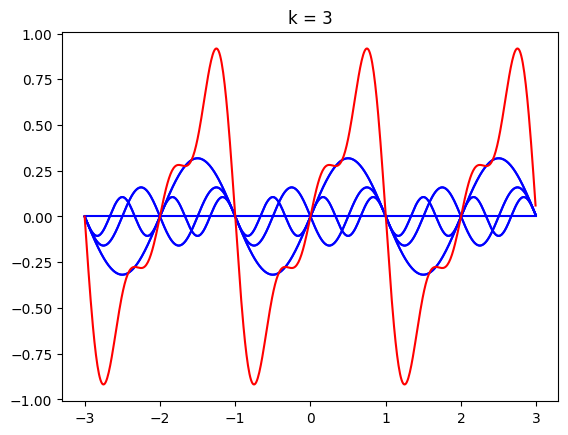

In [ ]:
t_0 = np.arange(-3,3,0.01)
x_t = np.zeros_like(t_0,dtype = 'complex128')

N = 3
for k in range(-N,N+1,1):
  x_t_k = (-1)**k * 1j / (k*np.pi + 1e-5) * np.e**(1j * np.pi * k * t_0)
  x_t += x_t_k
  plt.plot(t_0,x_t_k,color='b'); plt.title('k = '+str(k))

plt.plot(t_0,x_t,color='r')
plt.show()

## Lab 04

### Fourier series for Discrete-time signal

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:3387: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


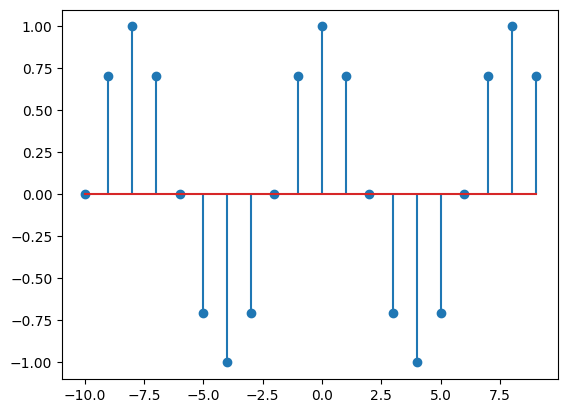

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k = 1
n = np.arange(-10,10,1)
x = np.e**(1j * (2 * k * np.pi)  * n/ 8)
plt.stem(n,x)
plt.show()

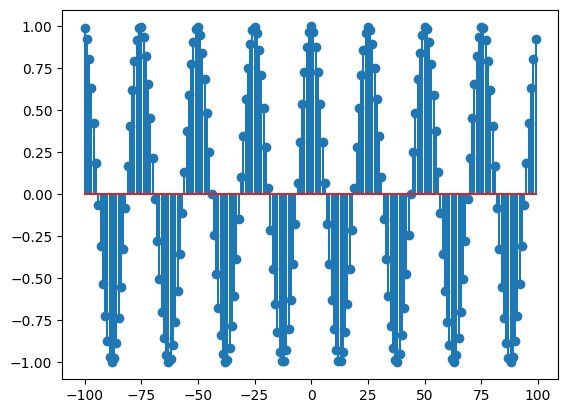

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k = 1
n = np.arange(-100,100,1)
x = np.e**(1j * (2 * k )  * n/ 8)
plt.stem(n,x)
plt.show()

/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:3377: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


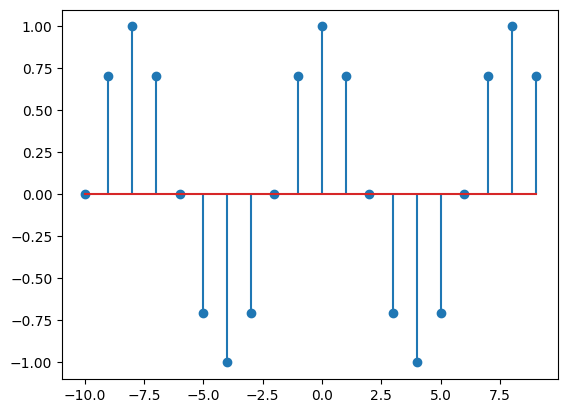

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

k = 1
n = np.arange(-10,10,1)
x = np.e**(1j * (2 * k* np.pi  * n/ 8 +2*np.pi))
plt.stem(n,x)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
N = ____
N1 = ____
K = np.arange(-40,41,1)
a_k = np.zeros(K.shape)

for k in K:
  if k % N == 0:
    # Fourier Series for k = 0,+/-2Pi,...
    a_k[k-K[0]] = ___________________________
  else:
    # Fourier Series for other k
    a_k[k-K[0]] = ____________________________

plt.figure(figsize=(20,3))
plt.stem(K,a_k)

plt.show()

## Lab 05

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal,fftpack

### Linear convolution
* np.convolve : https://numpy.org/doc/stable/reference/generated/numpy.convolve.html


[ 1  5  5 -5 -7  1  2]


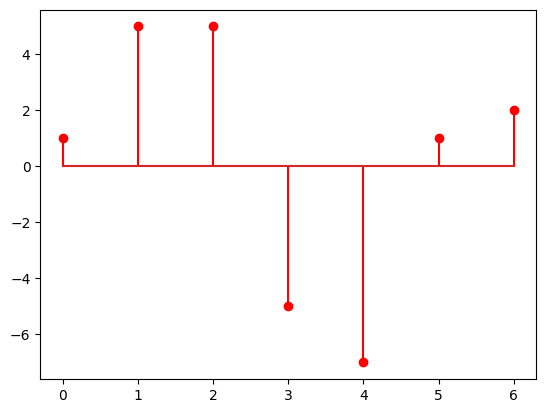

In [ ]:
x = [1,2,0,-1]
h = [1,3,-1,-2]
# linear convolution
y = np.convolve(h, x, mode = "full")
n = np.arange(0,len(y),1)

print(y)
plt.stem(n,y,'r',markerfmt='or')
plt.show()

### Circular shift
* low-high frequency
* calculate frequency
  * np.fft.fftfreq()

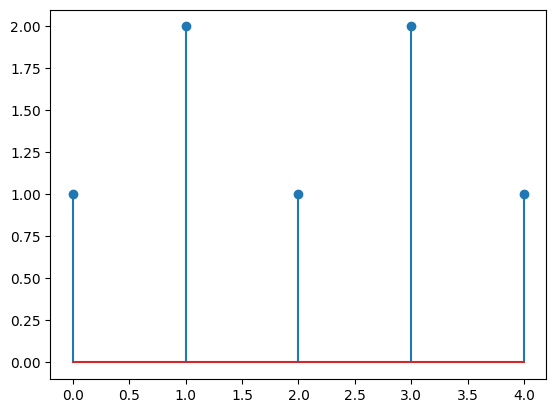

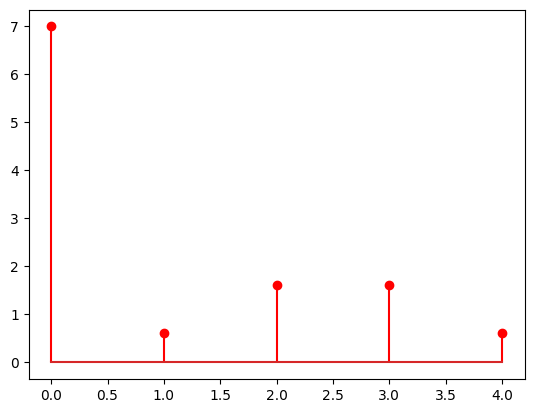

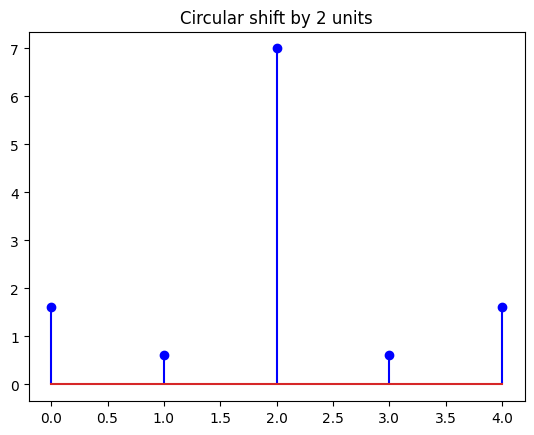

In [ ]:

x_n = [1,2,1,2,1] # N = 5
N = len(x_n)
n = np.arange(len(x_n))

X_k = np.fft.fft(x_n)

plt.stem(x_n)
plt.show()

plt.stem(np.abs(X_k),linefmt='r',markerfmt='or')
plt.show()

x_n_shift = x_n * np.e**(2j*n * 2 * np.pi / N)
X_k2 = np.fft.fft(x_n_shift)
plt.stem(np.abs(X_k2),linefmt='b',markerfmt='ob')
plt.title("Circular shift by 2 units")
plt.show()

[ 0.   0.2  0.4 -0.4 -0.2]


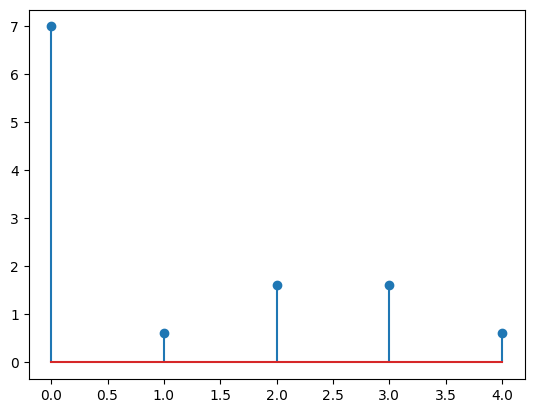

In [ ]:
x_n = [1,2,1,2,1] # N = 5
N = len(x_n)
n = np.arange(len(x_n))
f_k = np.fft.fftfreq(N)
print(f_k)

X_k = np.fft.fft(x_n)
plt.stem(np.abs(X_k))
plt.show()


f_k [ 0.    0.25 -0.5  -0.25]


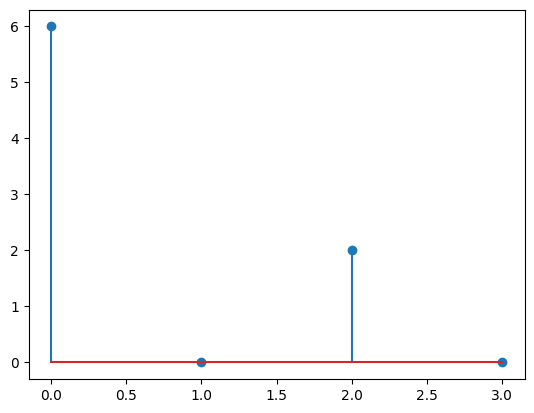

In [ ]:
x_n = [1,1,2,2] # N = 4
x_n = [1,2,1,2] # N = 4
N = len(x_n)
n = np.arange(len(x_n))
f_k = np.fft.fftfreq(N)
print("f_k",f_k)
X_k = np.fft.fft(x_n)

plt.stem(np.abs(X_k))
plt.show()


### Convolution in Frquency domain
* visualization


[  2. +0.j -13.-11.j  -0. +0.j -13.+11.j]


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:3377: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
/usr/local/lib/python3.10/dist-packages/matplotlib/cbook/__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


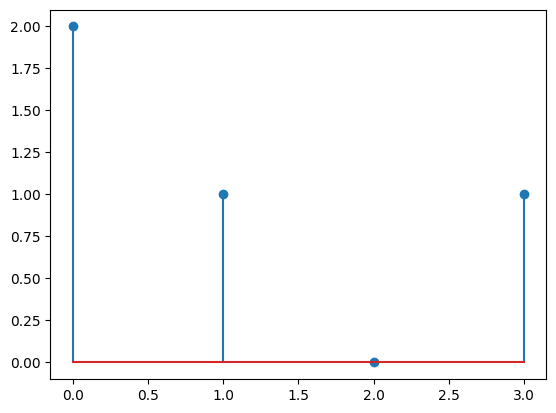

[-6.+0.j  6.+0.j  7.+0.j -5.+0.j]


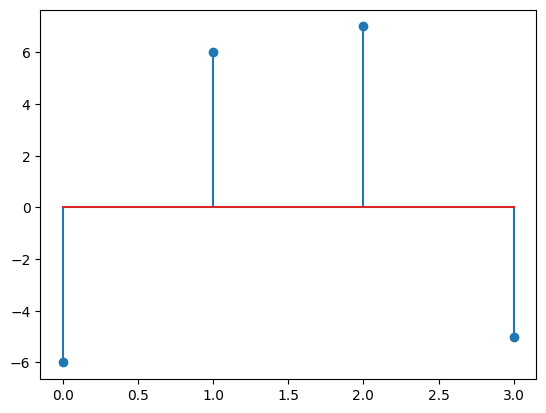

In [ ]:
x = [1,2,0,-1]
h = [1,3,-1,-2]

X_k = np.fft.fft(x)
H_k = np.fft.fft(h)

Y_k = X_k * H_k
y_n = np.fft.ifft(Y_k)
print(Y_k)


# print(X_k)
plt.stem(X_k)
plt.show()



print(y_n)
plt.stem(np.real(y_n))
plt.show()




# Lab 06 - Moving Average
* adjust M+N+1

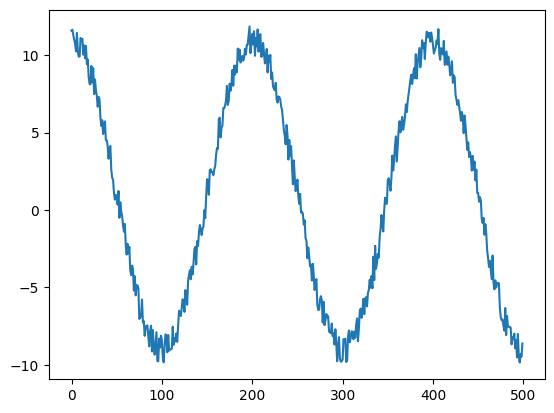

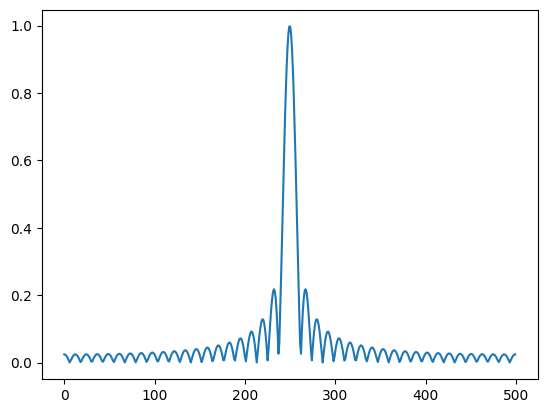

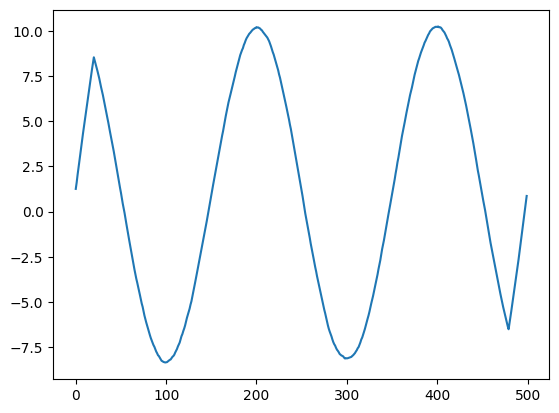

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# moving average of M + N + 1 points
M = 20
N = 20

# total number of points
N_points = 500

# strength of noise
s_noise = 2

# strength of signal
s_signal = 10

# generate a signal
n = np.arange(N_points)
x_n = s_noise*np.random.rand(N_points) + s_signal*np.cos(2*np.pi*n/200)
plt.plot(x_n)
plt.show()

# generate the transfer function H_e_jw
w = np.linspace(-np.pi,np.pi,N_points)
H_e_jw = 1/(M+N+1)*np.e**(1j*w *(N/2-M/2)) * np.sin(w/2*(M+N+1))/np.sin(w/2)
plt.plot(np.abs(H_e_jw))
plt.show()

X_e_jw = np.fft.fft(x_n)
# plt.plot(np.abs(X_e_jw))
# plt.title("fft")
# plt.show()


X_e_jw = np.fft.fftshift(X_e_jw)
# plt.plot(np.abs(X_e_jw))
# plt.title("fft shifted")
# plt.show()

# # filtering in frequency domain
# X_e_jw = np.fft.fftshift(np.fft.fft(x_n))
Y = H_e_jw * X_e_jw

# iDFT of the output Y
y = np.fft.ifft(np.fft.fftshift(Y))
plt.plot(np.real(y))
plt.show()
